# Programming Assignment 28
## Dimensionality Reduction using PCA – Iris Dataset

**Objective:** Apply Principal Component Analysis (PCA) to reduce the dimensionality of the Iris dataset. Standardize features, compute explained variance, and visualize the data in 2D space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### 1. Load Dataset

In [2]:
# Load Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame.copy()

feature_cols = iris.feature_names
target_col = "target"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature Columns:", feature_cols)
df.head()

Feature Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 2. Standardize Features
PCA is scale-sensitive, so standardization (mean=0, variance=1) is crucial.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check mean and std after scaling (should be close to 0 and 1)
print("Mean of scaled features:\n", np.mean(X_scaled, axis=0))
print("Std of scaled features:\n", np.std(X_scaled, axis=0))

Mean of scaled features:
 [-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
Std of scaled features:
 [1. 1. 1. 1.]


### 3. Fit PCA (All Components)

In [4]:
pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

# Explained variance table
ev_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance Ratio": explained_var,
    "Cumulative Variance": cum_explained_var
})
print("\n=== Explained Variance by Principal Components ===\n")
print(ev_df)


=== Explained Variance by Principal Components ===

    PC  Explained Variance Ratio  Cumulative Variance
0  PC1                  0.729624             0.729624
1  PC2                  0.228508             0.958132
2  PC3                  0.036689             0.994821
3  PC4                  0.005179             1.000000


### 4. Variance Visualization

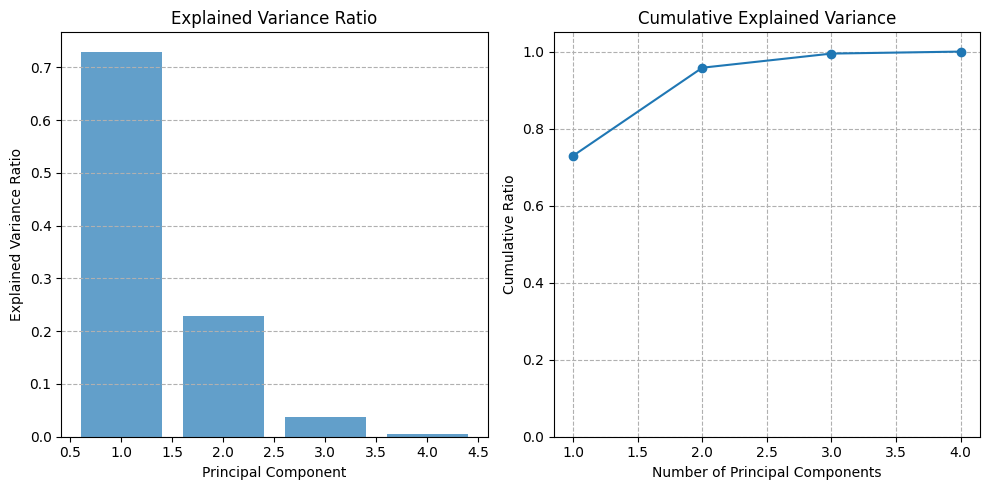

In [5]:
# Bar plot for Explained Variance Ratio
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7)
plt.title("Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(axis="y", linestyle="--")

# Line plot for Cumulative Explained Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o", linestyle="-")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)
plt.grid(linestyle="--")

plt.tight_layout()
plt.show()

### 5. Reduce to 2 Principal Components

In [6]:
pca2 = PCA(n_components=2)
X_pca_2 = pca2.fit_transform(X_scaled)

pca2_ev = pca2.explained_variance_ratio_
print("\n=== PCA with 2 Components ===")
print(f"Explained Variance PC1: {pca2_ev[0]:.4f}")
print(f"Explained Variance PC2: {pca2_ev[1]:.4f}")
print(f"Total Variance Explained: {pca2_ev.sum():.4f}")


=== PCA with 2 Components ===
Explained Variance PC1: 0.7296
Explained Variance PC2: 0.2285
Total Variance Explained: 0.9581


### 6. 2D Scatter Plot (PC1 vs PC2)

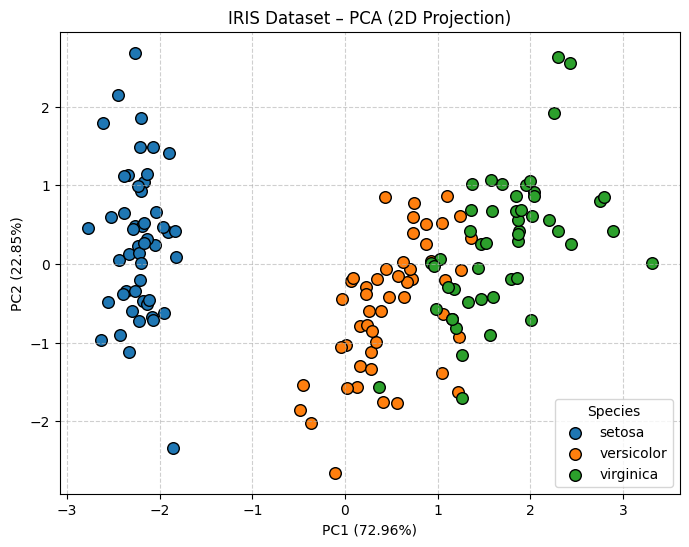

In [7]:
plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(iris.target_names):
    plt.scatter(
        X_pca_2[y == class_id, 0],
        X_pca_2[y == class_id, 1],
        label=class_name,
        edgecolor='k',
        s=70
    )

plt.title("IRIS Dataset – PCA (2D Projection)")
plt.xlabel(f"PC1 ({pca2_ev[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca2_ev[1]*100:.2f}%)")
plt.legend(title="Species")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### 7. Feature Contribution (Loadings)

=== Feature Loadings ===

                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942


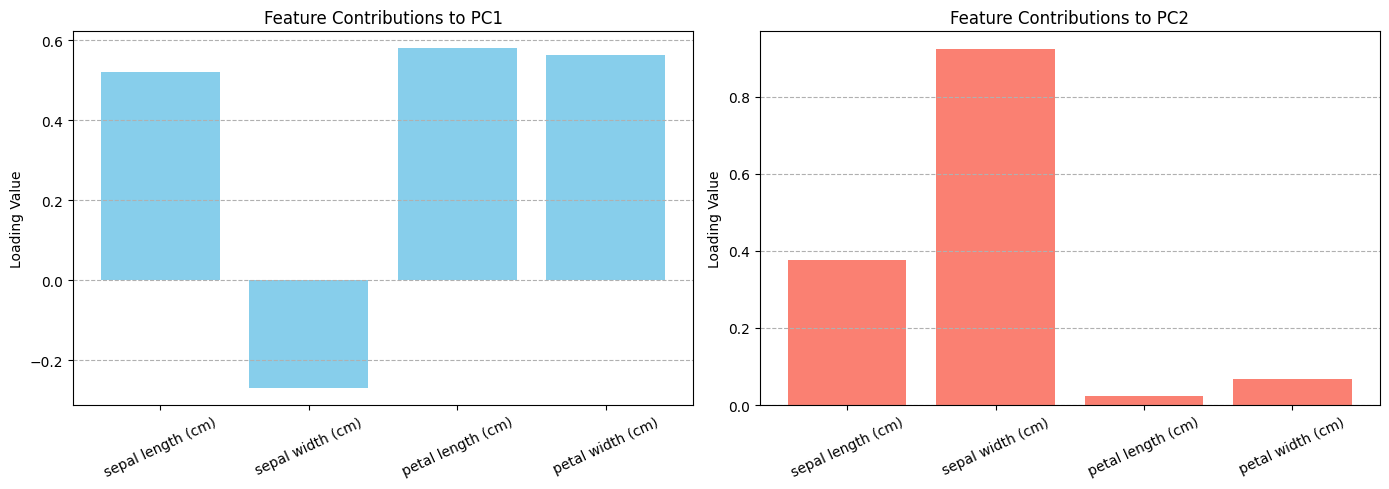

In [8]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)
print("=== Feature Loadings ===\n")
print(loadings)

# Plot Loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(loadings.index, loadings["PC1"], color='skyblue')
axes[0].set_title("Feature Contributions to PC1")
axes[0].set_ylabel("Loading Value")
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis="y", linestyle="--")

axes[1].bar(loadings.index, loadings["PC2"], color='salmon')
axes[1].set_title("Feature Contributions to PC2")
axes[1].set_ylabel("Loading Value")
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis="y", linestyle="--")

plt.tight_layout()
plt.show()

### 8. Convert Reduced Data to DataFrame

In [9]:
pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["target"] = y
pca_df["species"] = pca_df["target"].map({i: n for i, n in enumerate(iris.target_names)})

print("\n=== PCA Reduced Dataset (First 10 rows) ===\n")
print(pca_df.head(10))


=== PCA Reduced Dataset (First 10 rows) ===

        PC1       PC2  target species
0 -2.264703  0.480027       0  setosa
1 -2.080961 -0.674134       0  setosa
2 -2.364229 -0.341908       0  setosa
3 -2.299384 -0.597395       0  setosa
4 -2.389842  0.646835       0  setosa
5 -2.075631  1.489178       0  setosa
6 -2.444029  0.047644       0  setosa
7 -2.232847  0.223148       0  setosa
8 -2.334640 -1.115328       0  setosa
9 -2.184328 -0.469014       0  setosa
